# Пример на датасете

## Что мы должны получить из датасета

После запуска Colab должны получиться:

- краткое описание датасета;
- баланс классов;
- таблица top-признаков по четырём простым источникам;
- общий top-признаков по консенсусу;
- MFF-NoFit, то есть проверка top-признаков против случайных наборов;
- несколько понятных правил по интервалам;
- CSV-файлы для статьи.

Если студент не может объяснить, что означает его top-5 признаков, значит работа не закончена.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.datasets import load_breast_cancer
from scipy.stats import spearmanr

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

OUT_DIR = Path("xdm_simple_outputs")
OUT_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

print("Готово. Библиотеки подключены.")

Готово. Библиотеки подключены.


## 1. Загружаем датасет

В этом примере цель уже есть. Она называется `target`.

В этом датасете:

- строка означает один медицинский образец;
- признаки описывают характеристики клеточных ядер;
- целевая переменная показывает тип опухоли.

В своём датасете студент должен сам найти целевую переменную и написать, что она означает.

In [2]:
data = load_breast_cancer(as_frame=True)

df = data.frame.copy()
target_col = "target"

display(df.head())

print("Размер таблицы:", df.shape)
print("Целевая переменная:", target_col)
print("Классы:", dict(enumerate(data.target_names)))

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Размер таблицы: (569, 31)
Целевая переменная: target
Классы: {0: np.str_('malignant'), 1: np.str_('benign')}


## 2. Что нужно вытащить из таблицы в самом начале

Перед расчётами нужно понять таблицу. Это самый простой, но самый важный шаг.

Мы фиксируем число строк, число признаков, целевую переменную, баланс классов и пропуски.

In [3]:
feature_cols = [c for c in df.columns if c != target_col]

dataset_info = pd.DataFrame({
    "Что смотрим": [
        "Название датасета",
        "Количество строк",
        "Количество признаков",
        "Целевая переменная",
        "Пропусков всего",
        "Доля класса 0",
        "Доля класса 1"
    ],
    "Значение": [
        "Breast Cancer Wisconsin",
        len(df),
        len(feature_cols),
        target_col,
        int(df.isna().sum().sum()),
        round(float((df[target_col] == 0).mean()), 3),
        round(float((df[target_col] == 1).mean()), 3)
    ]
})

display(dataset_info)
dataset_info.to_csv(OUT_DIR / "dataset_info.csv", index=False)

,Что смотрим,Значение
0,Название датасета,Breast Cancer Wisconsin
1,Количество строк,569
2,Количество признаков,30
3,Целевая переменная,target
4,Пропусков всего,0
5,Доля класса 0,0.373
6,Доля класса 1,0.627


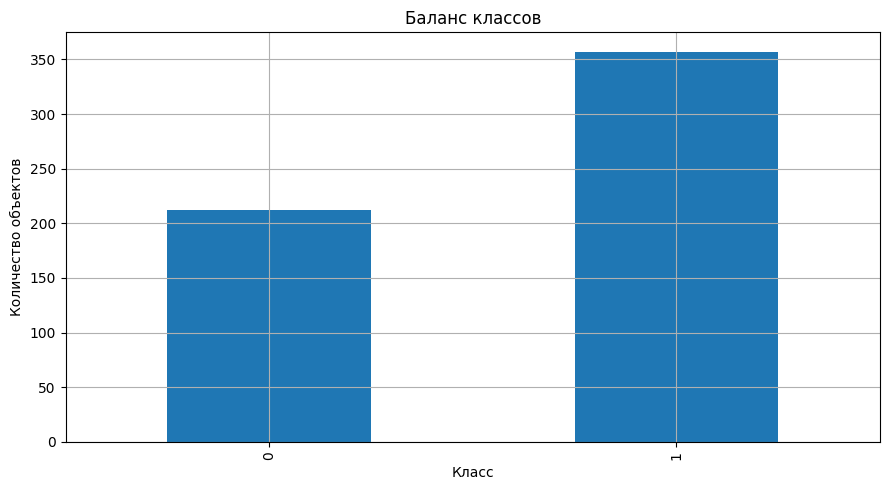

In [4]:
class_counts = df[target_col].value_counts().sort_index()

ax = class_counts.plot(kind="bar")
ax.set_title("Баланс классов")
ax.set_xlabel("Класс")
ax.set_ylabel("Количество объектов")
plt.tight_layout()
plt.show()

## 3. Небольшая предобработка

Если в таблице есть пропуски, числовые признаки заполняются медианой. Затем признаки приводятся к одному масштабу. Это нужно для расстояний. Масштабирование не является обучением модели. Мы просто вычитаем среднее и делим на стандартное отклонение.

In [5]:
work_df = df.copy()

for c in feature_cols:
    if work_df[c].isna().sum() > 0:
        work_df[c] = work_df[c].fillna(work_df[c].median())

X_raw = work_df[feature_cols].copy()
y = work_df[target_col].copy()

mean_values = X_raw.mean()
std_values = X_raw.std().replace(0, 1)

X = (X_raw - mean_values) / std_values

print("Пропусков после обработки:", int(X.isna().sum().sum()))
display(X.head())

Пропусков после обработки: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.096100,-2.071512,1.268817,0.983510,1.567087,3.280628,2.650542,2.530249,2.215566,2.253764,...,1.885031,-1.358098,2.301575,1.999478,1.306537,2.614365,2.107672,2.294058,2.748204,1.935312
1,1.828212,-0.353322,1.684473,1.907030,-0.826235,-0.486643,-0.023825,0.547662,0.001391,-0.867889,...,1.804340,-0.368879,1.533776,1.888827,-0.375282,-0.430066,-0.146620,1.086129,-0.243675,0.280943
2,1.578499,0.455786,1.565126,1.557513,0.941382,1.052000,1.362280,2.035440,0.938859,-0.397658,...,1.510541,-0.023953,1.346291,1.455004,0.526944,1.081980,0.854222,1.953282,1.151242,0.201214
3,-0.768233,0.253509,-0.592166,-0.763792,3.280667,3.399917,1.914213,1.450431,2.864862,4.906602,...,-0.281217,0.133866,-0.249720,-0.549538,3.391291,3.889975,1.987839,2.173873,6.040726,4.930672
4,1.748758,-1.150804,1.775011,1.824624,0.280125,0.538866,1.369806,1.427237,-0.009552,-0.561956,...,1.297434,-1.465481,1.337363,1.219651,0.220362,-0.313119,0.612640,0.728618,-0.867590,-0.396751


## 4. Вспомогательные функции

Эти функции нужны для расчёта важности признаков.

Здесь нет обучения. Все функции работают напрямую с таблицей, значениями признаков и целевой переменной.

In [6]:
def normalize_score(s):
    s = pd.Series(s, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    s = s - s.min()
    if s.max() == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return s / s.max()

def rank_score(s):
    s = pd.Series(s, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return s.rank(ascending=False, method="average")

def pairwise_distances(A):
    A = np.asarray(A, dtype=float)
    aa = np.sum(A * A, axis=1)[:, None]
    d2 = np.maximum(aa + aa.T - 2 * A @ A.T, 0.0)
    return np.sqrt(d2)

def distance_structure_score(X_part, y_part):
    A = np.asarray(X_part, dtype=float)
    y_arr = np.asarray(y_part)
    if A.ndim == 1:
        A = A.reshape(-1, 1)
    D = pairwise_distances(A)
    i, j = np.triu_indices_from(D, k=1)
    same = y_arr[i] == y_arr[j]
    intra = D[i, j][same].mean()
    inter = D[i, j][~same].mean()
    return (inter - intra) / (abs(inter) + abs(intra) + 1e-12)

print("Функции готовы.")

Функции готовы.


## 5. Источник 1: статистическая связь

Здесь мы смотрим, насколько каждый признак связан с целевой переменной.

Для простоты используется ранговая корреляция. Если связь сильная, признак получает высокий балл. Это не означает, что признак является причиной. Это означает только то, что в этой таблице он заметно связан с целью.

In [7]:
stat_scores = {}

for c in feature_cols:
    corr, _ = spearmanr(X[c], y)
    stat_scores[c] = abs(corr) if not np.isnan(corr) else 0.0

stat_scores = normalize_score(pd.Series(stat_scores, name="statistical_score"))

display(stat_scores.sort_values(ascending=False).head(10).to_frame())

,statistical_score
worst perimeter,1.000000
worst radius,0.989206
worst area,0.987879
worst concave points,0.981149
mean concave points,0.976263
mean perimeter,0.938444
mean area,0.919943
mean concavity,0.918895
mean radius,0.918222
area error,0.894279


## 6. Источник 2: геометрический вклад

Теперь смотрим на расстояния между объектами.

Если признак важен, то при его удалении классы должны разделяться хуже. Поэтому мы по очереди удаляем каждый признак и смотрим, насколько падает разделение классов.

In [8]:
base_geometry = distance_structure_score(X, y)

geom_scores = {}
for c in feature_cols:
    remaining = [v for v in feature_cols if v != c]
    without_c = distance_structure_score(X[remaining], y)
    geom_scores[c] = max(base_geometry - without_c, 0.0)

geom_scores = normalize_score(pd.Series(geom_scores, name="geometric_score"))

display(geom_scores.sort_values(ascending=False).head(10).to_frame())

,geometric_score
worst perimeter,1.000000
worst radius,0.993247
mean concave points,0.961326
worst area,0.936184
worst concave points,0.903871
mean area,0.782572
mean perimeter,0.779290
mean radius,0.732494
mean concavity,0.685813
area error,0.479372


## 7. Источник 3: условная связность

Некоторые признаки повторяют друг друга. Например, радиус, площадь и периметр могут быть связаны между собой.

Условная связность проверяет, остаётся ли связь признака с целью, если учитывать общую структуру остальных признаков. Это не причинность. Это осторожная проверка связи на фоне других переменных.

In [9]:
Xy = X.copy()
Xy["target"] = y.values

Z = (Xy - Xy.mean()) / Xy.std().replace(0, 1)
cov = np.cov(Z.values, rowvar=False)
precision = np.linalg.pinv(cov)

target_idx = Z.columns.get_loc("target")

conditional_scores = {}
for i, c in enumerate(feature_cols):
    denom = np.sqrt(abs(precision[i, i] * precision[target_idx, target_idx])) + 1e-12
    partial_corr = -precision[i, target_idx] / denom
    conditional_scores[c] = abs(float(partial_corr))

conditional_scores = normalize_score(pd.Series(conditional_scores, name="conditional_score"))

display(conditional_scores.sort_values(ascending=False).head(10).to_frame())

,conditional_score
worst radius,1.000000
mean compactness,0.941210
worst area,0.940530
concavity error,0.816598
smoothness error,0.713890
concave points error,0.578933
worst fractal dimension,0.539453
worst concavity,0.424048
radius error,0.418631
mean concavity,0.399408


## 8. Источник 4: простые правила

Теперь ищем правила по интервалам.

Например: если значение признака попадает в верхний интервал, то доля класса 1 становится выше или ниже обычной. Такие правила удобны, потому что их можно объяснить словами.

In [10]:
def make_bins(x, bins=5):
    try:
        return pd.qcut(x, q=bins, duplicates="drop")
    except Exception:
        return pd.cut(x, bins=bins, duplicates="drop")

base_rate = y.mean()
rule_rows = []
rule_scores = pd.Series(0.0, index=feature_cols)

for c in feature_cols:
    binned = make_bins(X[c], bins=5)
    for interval in binned.dropna().unique():
        mask = (binned == interval)
        support = int(mask.sum())
        if support < 10:
            continue
        target_rate = float(y[mask].mean())
        coverage = float(mask.mean())
        score = coverage * abs(target_rate - base_rate)
        rule_rows.append({
            "feature": c,
            "interval": str(interval),
            "objects_in_rule": support,
            "target_rate_in_rule": round(target_rate, 3),
            "base_target_rate": round(float(base_rate), 3),
            "rule_score": score
        })

rules_df = pd.DataFrame(rule_rows).sort_values("rule_score", ascending=False)

for c, part in rules_df.head(30).groupby("feature"):
    rule_scores[c] = part["rule_score"].sum()

rule_scores = normalize_score(rule_scores.rename("rule_score"))

display(rules_df.head(10))
display(rule_scores.sort_values(ascending=False).head(10).to_frame())

rules_df.to_csv(OUT_DIR / "top_rules.csv", index=False)

,feature,interval,objects_in_rule,target_rate_in_rule,base_target_rate,rule_score
100,worst radius,"(0.833, 4.091]",114,0.000,0.627,0.125704
135,worst concave points,"(0.957, 2.684]",114,0.000,0.627,0.125704
110,worst perimeter,"(0.781, 4.284]",113,0.000,0.627,0.124601
115,worst area,"(0.682, 5.925]",113,0.000,0.627,0.124601
0,mean radius,"(0.834, 3.968]",114,0.009,0.627,0.123946
10,mean perimeter,"(0.811, 3.973]",114,0.009,0.627,0.123946
15,mean area,"(0.739, 5.246]",114,0.009,0.627,0.123946
35,mean concave points,"(0.911, 3.924]",114,0.009,0.627,0.123946
65,area error,"(0.302, 11.032]",114,0.009,0.627,0.123946
30,mean concavity,"(0.765, 4.24]",114,0.061,0.627,0.113402


,rule_score
worst perimeter,1.000000
worst concave points,0.991078
worst concavity,0.893579
worst radius,0.740995
worst area,0.736917
mean concave points,0.734495
mean perimeter,0.727996
area error,0.723917
mean radius,0.721496
mean area,0.714996


## 9. Смотрим top-10 по каждому источнику

Теперь у нас есть четыре списка важности. Каждый список показывает свой взгляд на таблицу. Если признак повторяется в нескольких списках, это хороший знак.

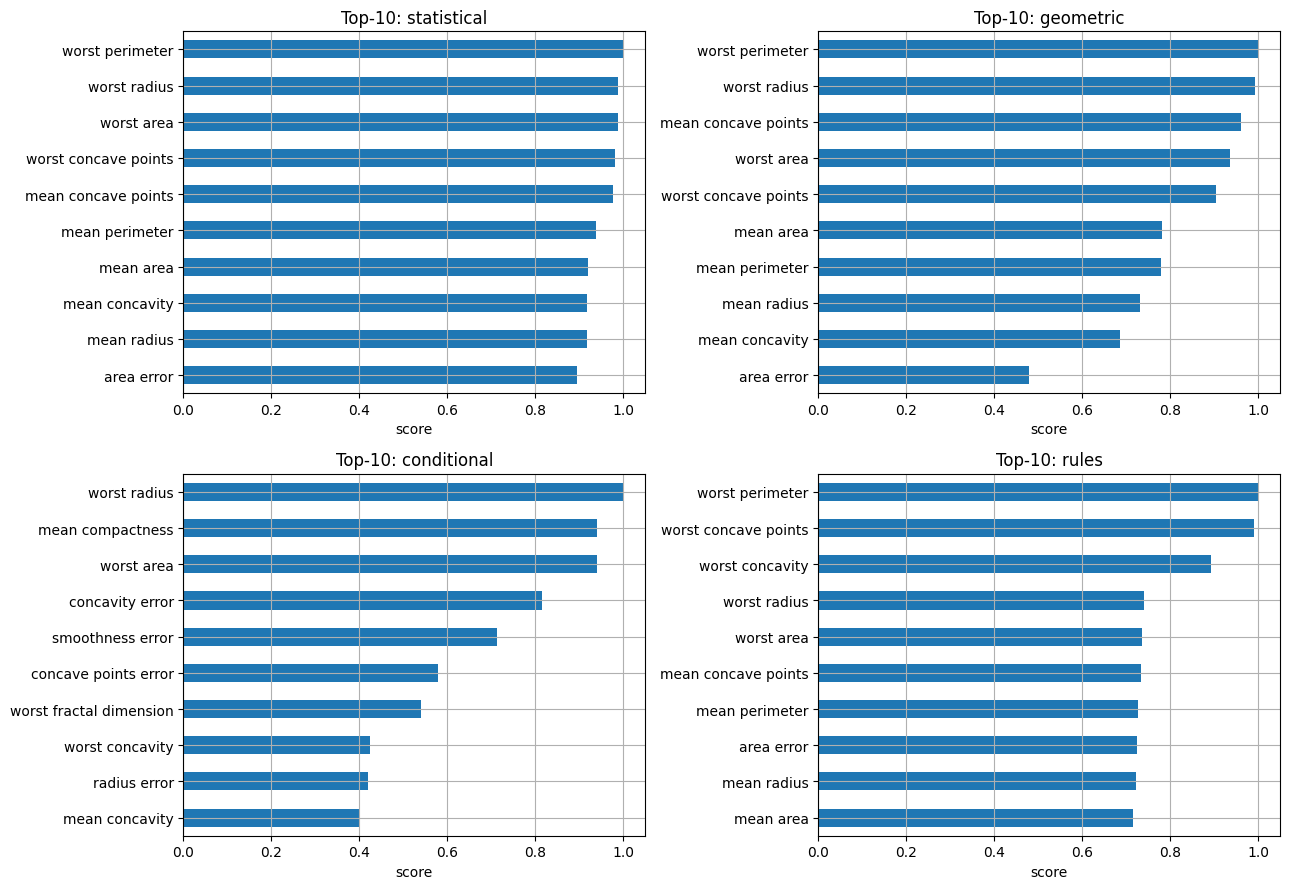

In [11]:
scores_df = pd.DataFrame({
    "statistical": stat_scores,
    "geometric": geom_scores,
    "conditional": conditional_scores,
    "rules": rule_scores
})

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col in zip(axes.ravel(), scores_df.columns):
    top = scores_df[col].sort_values(ascending=True).tail(10)
    top.plot(kind="barh", ax=ax)
    ax.set_title("Top-10: " + col)
    ax.set_xlabel("score")

plt.tight_layout()
plt.show()

## 10. Собираем консенсус

Оценки имеют разные шкалы, поэтому их нельзя просто складывать.

Сначала переводим каждую оценку в ранг. Ранг 1 означает лучший признак. Затем считаем средний ранг по четырём источникам. Чем меньше средний ранг, тем выше признак в общем списке.

In [12]:
ranks_df = scores_df.apply(rank_score, axis=0)
ranks_df["mean_rank"] = ranks_df.mean(axis=1)
ranks_df["rank_iqr"] = ranks_df[scores_df.columns].quantile(0.75, axis=1) - ranks_df[scores_df.columns].quantile(0.25, axis=1)
ranks_df["stable"] = ranks_df["rank_iqr"] <= ranks_df["rank_iqr"].median()

result_df = ranks_df.sort_values(["mean_rank", "rank_iqr"])
result_df.to_csv(OUT_DIR / "feature_ranks.csv", index=True)

display(result_df.head(15))

,statistical,geometric,conditional,rules,mean_rank,rank_iqr,stable
worst radius,2.0,2.0,1.0,4.0,2.250,0.750,True
worst area,3.0,4.0,3.0,5.0,3.750,1.250,True
worst perimeter,1.0,1.0,23.0,1.0,6.500,5.500,False
mean concave points,5.0,3.0,13.0,6.0,6.750,3.250,False
worst concavity,11.0,11.0,8.0,3.0,8.250,4.250,False
worst concave points,4.0,5.0,22.0,2.0,8.250,5.750,False
mean perimeter,6.0,7.0,15.0,7.0,8.750,2.250,True
mean radius,9.0,8.0,11.0,9.0,9.250,0.750,True
mean concavity,8.0,9.0,10.0,11.0,9.500,1.500,True
mean area,7.0,6.0,19.0,10.0,10.500,5.500,False


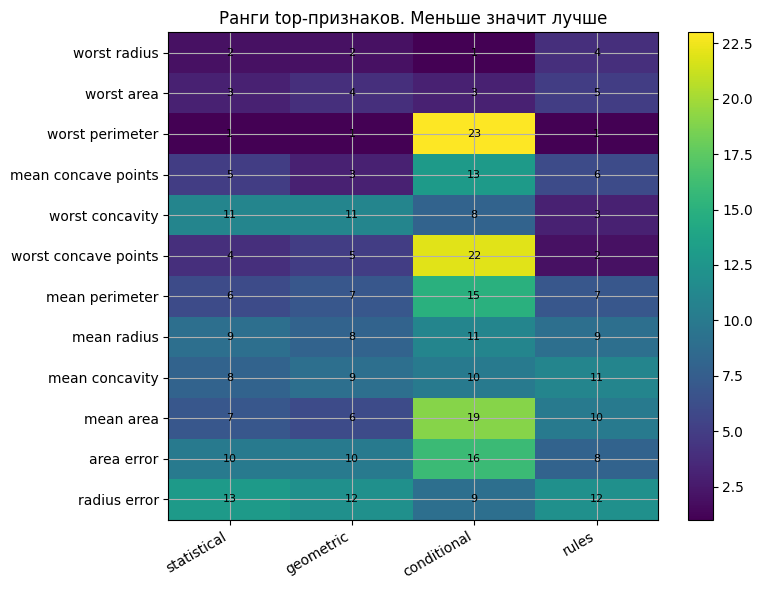

In [13]:
top_features = result_df.head(12).index.tolist()
heat_data = result_df.loc[top_features, scores_df.columns]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heat_data.values, aspect="auto")
ax.set_xticks(range(len(scores_df.columns)))
ax.set_xticklabels(scores_df.columns, rotation=30, ha="right")
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features)

for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        ax.text(j, i, str(int(heat_data.values[i, j])), ha="center", va="center", fontsize=8)

ax.set_title("Ранги top-признаков. Меньше значит лучше")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 11. MFF-NoFit: проверяем, что top-признаки лучше случайных

Берём top-k признаков по консенсусу. Считаем, насколько хорошо они сохраняют различие между классами по расстояниям.

Потом много раз берём случайные k признаков и считаем то же самое. Если наш top-k лучше случайного фона, MFF-NoFit положительный.

In [14]:
def mff_nofit(result_df, X, y, k=5, repeats=200):
    all_features = result_df.index.tolist()
    top_k = result_df.head(k).index.tolist()
    consensus_score = distance_structure_score(X[top_k], y)

    random_scores = []
    for _ in range(repeats):
        random_k = rng.choice(all_features, size=k, replace=False).tolist()
        random_scores.append(distance_structure_score(X[random_k], y))

    random_scores = np.array(random_scores)
    mff = consensus_score - random_scores.mean()
    p_value = (np.sum(random_scores >= consensus_score) + 1) / (len(random_scores) + 1)

    return {
        "k": k,
        "consensus_score": consensus_score,
        "random_mean": random_scores.mean(),
        "MFF_NoFit": mff,
        "p_value": p_value,
        "top_features": ", ".join(top_k)
    }, random_scores

mff_rows = []
random_distributions = {}

for k in [5, 10, 15]:
    row, random_scores = mff_nofit(result_df, X, y, k=k, repeats=200)
    mff_rows.append(row)
    random_distributions[k] = random_scores

mff_df = pd.DataFrame(mff_rows)
mff_df.to_csv(OUT_DIR / "mff_nofit_results.csv", index=False)

display(mff_df)

,k,consensus_score,random_mean,MFF_NoFit,p_value,top_features
0,5,0.410149,0.202423,0.207726,0.009950,"worst radius, worst area, worst perimeter, mea..."
1,10,0.394512,0.203852,0.190659,0.004975,"worst radius, worst area, worst perimeter, mea..."
2,15,0.346855,0.200189,0.146666,0.004975,"worst radius, worst area, worst perimeter, mea..."


/tmp/ipykernel_4003/3823753263.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=["k=5", "k=10", "k=15"])


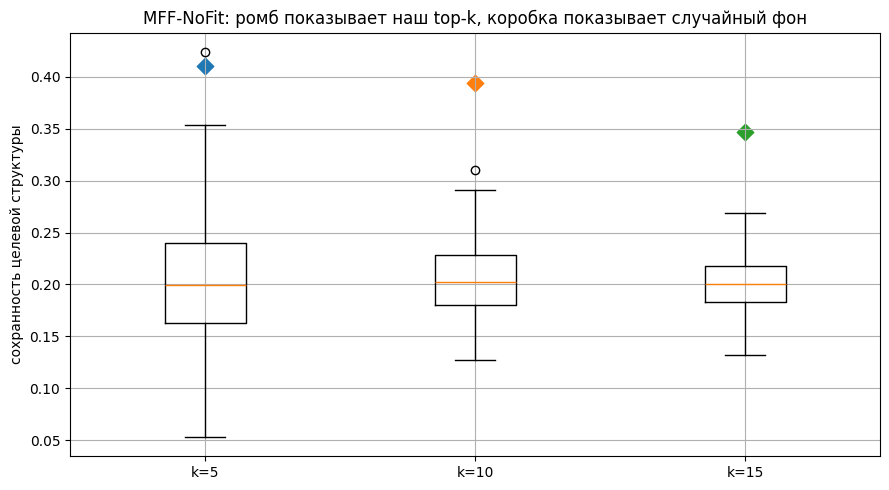

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

box_data = [random_distributions[k] for k in [5, 10, 15]]
ax.boxplot(box_data, labels=["k=5", "k=10", "k=15"])

for i, k in enumerate([5, 10, 15], start=1):
    consensus_value = mff_df.loc[mff_df["k"] == k, "consensus_score"].iloc[0]
    ax.scatter(i, consensus_value, marker="D", s=70)

ax.set_title("MFF-NoFit: ромб показывает наш top-k, коробка показывает случайный фон")
ax.set_ylabel("сохранность целевой структуры")
plt.tight_layout()
plt.show()

## 12. Устойчивость top-признаков

Теперь проверим, какие признаки часто попадают в top-10, если немного менять строки датасета.

Это нужно для статьи. Признак считается более надёжным, если он появляется в top-10 не один раз, а стабильно при разных пересэмплингах.

In [16]:
def calculate_scores_for_sample(X_sample, y_sample):
    sample_feature_cols = X_sample.columns.tolist()

    stat = {}
    for c in sample_feature_cols:
        corr, _ = spearmanr(X_sample[c], y_sample)
        stat[c] = abs(corr) if not np.isnan(corr) else 0.0
    stat = normalize_score(pd.Series(stat))

    base = distance_structure_score(X_sample, y_sample)
    geo = {}
    for c in sample_feature_cols:
        remaining = [v for v in sample_feature_cols if v != c]
        geo[c] = max(base - distance_structure_score(X_sample[remaining], y_sample), 0.0)
    geo = normalize_score(pd.Series(geo))

    Xy_local = X_sample.copy()
    Xy_local["target"] = np.asarray(y_sample)
    Z_local = (Xy_local - Xy_local.mean()) / Xy_local.std().replace(0, 1)
    precision_local = np.linalg.pinv(np.cov(Z_local.values, rowvar=False))
    target_local_idx = Z_local.columns.get_loc("target")
    cond = {}
    for i, c in enumerate(sample_feature_cols):
        denom = np.sqrt(abs(precision_local[i, i] * precision_local[target_local_idx, target_local_idx])) + 1e-12
        cond[c] = abs(float(-precision_local[i, target_local_idx] / denom))
    cond = normalize_score(pd.Series(cond))

    # Для ускорения bootstrap здесь используем три источника без правил.
    sample_scores = pd.DataFrame({
        "statistical": stat,
        "geometric": geo,
        "conditional": cond
    })
    sample_ranks = sample_scores.apply(rank_score, axis=0)
    sample_ranks["mean_rank"] = sample_ranks.mean(axis=1)
    return sample_ranks.sort_values("mean_rank")

top10_count = pd.Series(0, index=feature_cols, dtype=float)
repeats = 15

for _ in range(repeats):
    idx = rng.choice(np.arange(len(X)), size=int(0.8 * len(X)), replace=True)
    X_sample = X.iloc[idx].reset_index(drop=True)
    y_sample = y.iloc[idx].reset_index(drop=True)
    sample_rank = calculate_scores_for_sample(X_sample, y_sample)
    top10_count.loc[sample_rank.head(10).index] += 1

stability_df = pd.DataFrame({
    "feature": top10_count.index,
    "top10_frequency": top10_count.values / repeats
}).sort_values("top10_frequency", ascending=False)

stability_df.to_csv(OUT_DIR / "bootstrap_stability.csv", index=False)
display(stability_df.head(15))

,feature,top10_frequency
23,worst area,1.000000
20,worst radius,1.000000
27,worst concave points,1.000000
22,worst perimeter,0.933333
0,mean radius,0.866667
5,mean compactness,0.866667
7,mean concave points,0.866667
2,mean perimeter,0.733333
6,mean concavity,0.600000
3,mean area,0.600000


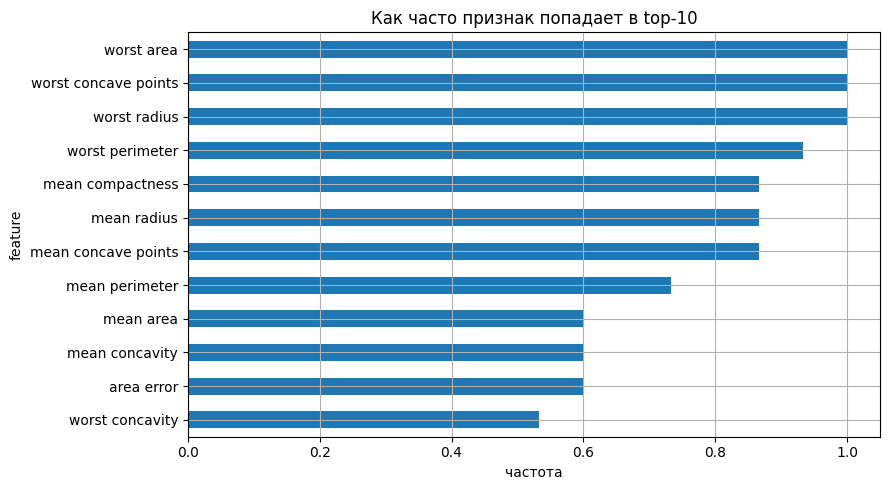

In [17]:
top_stability = stability_df.head(12).sort_values("top10_frequency")

ax = top_stability.plot(x="feature", y="top10_frequency", kind="barh", legend=False)
ax.set_title("Как часто признак попадает в top-10")
ax.set_xlabel("частота")
plt.tight_layout()
plt.show()

## 13. Короткий итог по датасету

Теперь нужно написать вывод своими словами.

In [18]:
top5 = result_df.head(5).index.tolist()
stable_count = int(result_df["stable"].sum())
best_mff = mff_df.loc[mff_df["k"] == 5, "MFF_NoFit"].iloc[0]
best_rule = rules_df.iloc[0]

summary_text = f'''
Краткий вывод по датасету:

1. В датасете {len(df)} объектов и {len(feature_cols)} признаков.
2. Целевая переменная: {target_col}.
3. В общий top-5 вошли признаки: {", ".join(top5)}.
4. Устойчивых признаков по IQR-фильтру: {stable_count}.
5. MFF-NoFit при k=5 равен {best_mff:.4f}. Если значение положительное, значит top-5 по консенсусу лучше случайного набора признаков.
6. Самое сильное найденное правило связано с признаком {best_rule["feature"]} и интервалом {best_rule["interval"]}.
'''

print(summary_text)

with open(OUT_DIR / "student_summary_template.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)


Краткий вывод по датасету:

1. В датасете 569 объектов и 30 признаков.
2. Целевая переменная: target.
3. В общий top-5 вошли признаки: worst radius, worst area, worst perimeter, mean concave points, worst concavity.
4. Устойчивых признаков по IQR-фильтру: 15.
5. MFF-NoFit при k=5 равен 0.2077. Если значение положительное, значит top-5 по консенсусу лучше случайного набора признаков.
6. Самое сильное найденное правило связано с признаком worst radius и интервалом (0.833, 4.091].



## 14. Какие файлы сдавать

После запуска Colab в папке `xdm_simple_outputs` появятся файлы:

`dataset_info.csv` — краткое описание датасета.

`feature_ranks.csv` — ранги признаков и общий консенсус.

`mff_nofit_results.csv` — проверка MFF-NoFit.

`bootstrap_stability.csv` — устойчивость признаков.

`top_rules.csv` — простые правила по интервалам.

`student_summary_template.txt` — заготовка вывода, которую нужно переписать своими словами.

In [19]:
print("Готовые файлы:")
for path in sorted(OUT_DIR.glob("*")):
    print(path)

Готовые файлы:
xdm_simple_outputs/bootstrap_stability.csv
xdm_simple_outputs/dataset_info.csv
xdm_simple_outputs/feature_ranks.csv
xdm_simple_outputs/mff_nofit_results.csv
xdm_simple_outputs/student_summary_template.txt
xdm_simple_outputs/top_rules.csv
